# Espectrograma

Neste notebook avaliamos o espectograma. Esta é uma ferramenta que nos permite avaliar a evolução do espectro no tempo. Basicamente tomamos transformadas de Fourier de pequenas janelas temporais que vão se deslocando com o tempo. Geramos então um mapa de cores em que a cor representa a magintude do espectro vs. tempo vs. frequência.

In [1]:
# importar as bibliotecas necessárias
import numpy as np # arrays
import matplotlib.pyplot as plt # plots
plt.rcParams.update({'font.size': 14})
from scipy import signal
import IPython.display as ipd # to play signals
import sounddevice as sd
import soundfile as sf

In [63]:
##### x(t) Grilo #################
xg, Fs = sf.read('FallFieldCricket.wav')
xt = xg[:,0]
time = np.linspace(0, (len(xg)-1)/Fs, len(xg))

In [76]:
##### x(t) Clarinete #################
xg, Fs = sf.read('B_Clarinet.wav')
tg = np.linspace(0, (len(xg)-1)/Fs, len(xg))

time = tg[tg<=18]
xt = xg[tg<=18]

In [31]:
#### Ruído branco ######################
Fs = 44100
time = np.arange(0, 4, 1/Fs)
xt = np.random.normal(loc = 0, scale = 1, size = len(time))

In [57]:
#### Sweep  ######################
Fs = 44100
time = np.arange(0, 4, 1/Fs)
xt = signal.chirp(time, 100, time[-1], 8000, method='linear') #'logarithmic'

# Os parâmetros do espectograma

Dê uma olhada na documentação do scipy:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.spectrogram.html


- O sinal no tempo
- A frequência de amostragem
- window: A janela temporal desejada
- Overlap: Número de pontos em que teremos uma sobreposição das janelas.
- nfft: Número de pontos da fft (zero padding). Se não for fornecido, é o número de pontos na janela temporal.

## Sem overlap

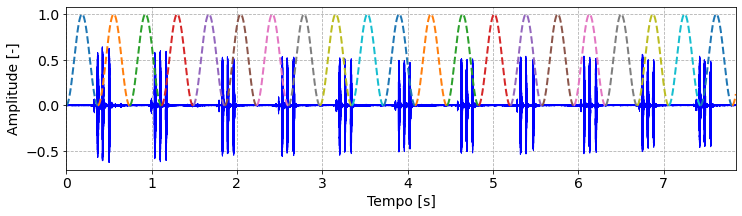

## Com overlap

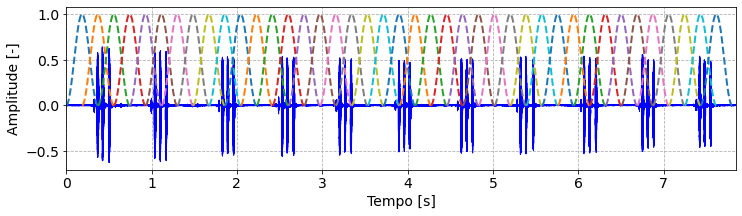

Note que quanto maior for sua janela, mais resolução você terá no espectro. No entanto, você vai perdendo informações sobre a mudança do espectro com o tempo.

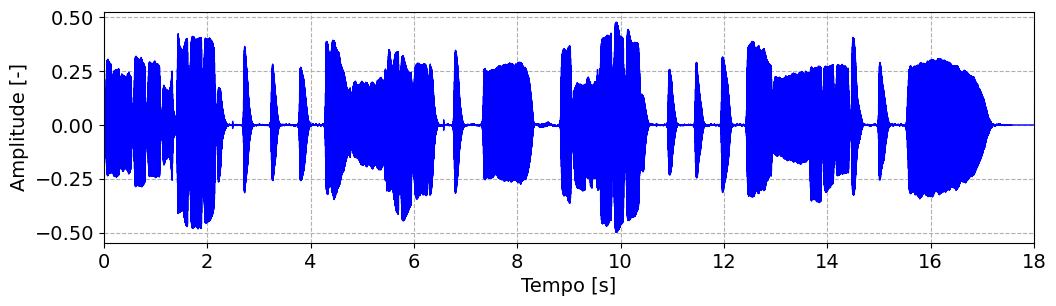

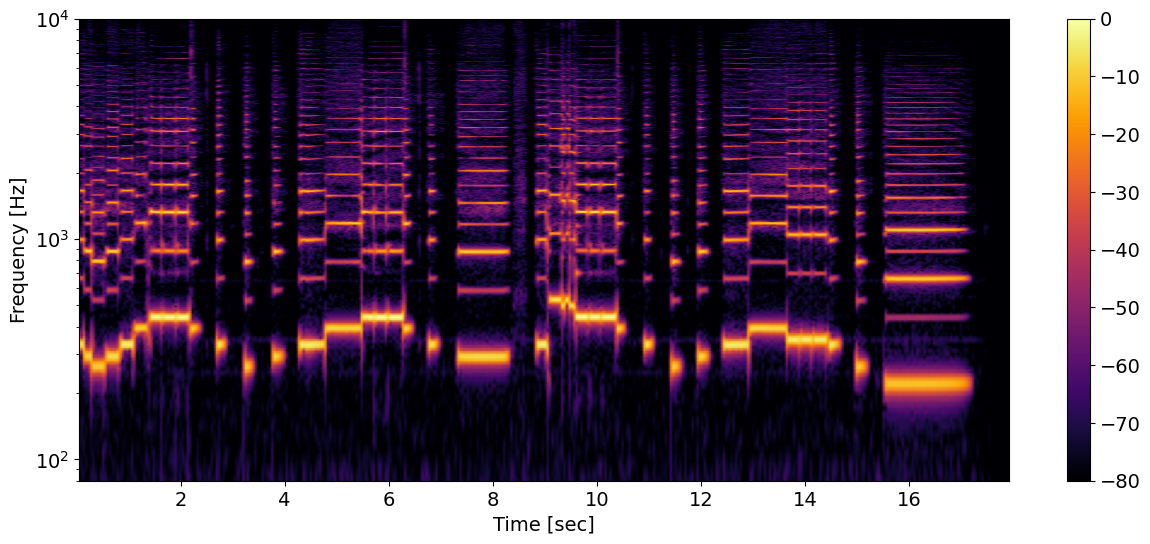

In [80]:
win = signal.windows.hann(4096)
f, t, Sxx = signal.spectrogram(xt, Fs, window = win, noverlap = len(win)/2, scaling = 'spectrum')

plt.figure(figsize=(12,3))
plt.plot(time, xt, '-b', linewidth = 1)
plt.grid(linestyle = '--', which='both')
plt.xlabel('Tempo [s]')
plt.ylabel('Amplitude [-]')
plt.xlim((0, time[-1]))


plt.figure(figsize=(15,6))
p = plt.pcolormesh(t, f, 10*np.log10(Sxx/np.amax(Sxx)), shading='gouraud', vmin = -80, cmap = 'inferno')
plt.colorbar(p)
plt.ylim((80, 10000))
plt.yscale('log')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

ipd.Audio(xt, rate=Fs) # load a NumPy array

In [53]:
print(t.shape)
print(f.shape)
print(Sxx.shape)

(42,)
(4097,)
(4097, 42)


In [55]:
t[1]

0.18575963718820862

In [15]:
(1/44100)*512

0.011609977324263039

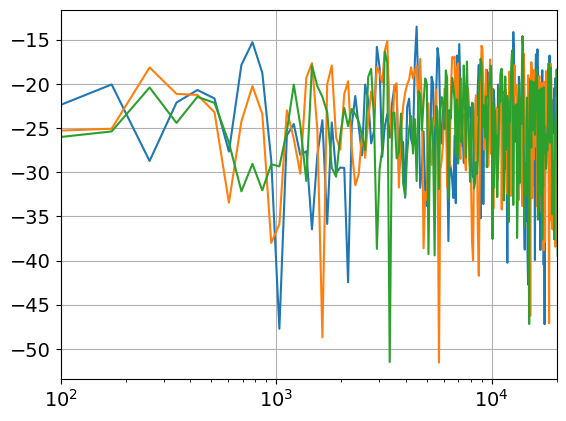

In [17]:
plt.figure()
plt.semilogx(f, 10*np.log10(np.abs(Sxx[:, 0])))
plt.semilogx(f, 10*np.log10(np.abs(Sxx[:, 1])))
plt.semilogx(f, 10*np.log10(np.abs(Sxx[:, 2])))

plt.grid()
plt.xlim((100, 20000));

In [19]:
Sxx_mean = np.mean(Sxx, axis = 1)

In [21]:
Sxx_mean.shape

(257,)

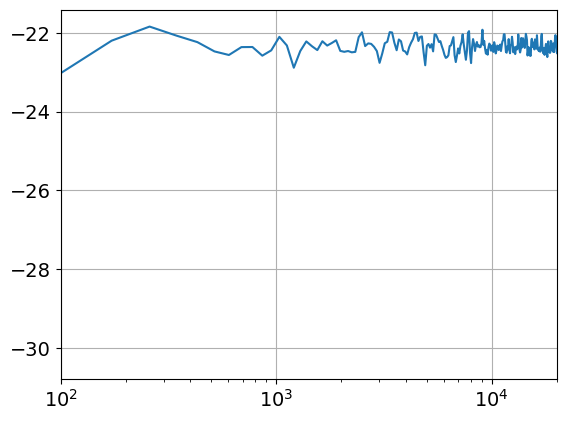

In [23]:
plt.figure()
plt.semilogx(f, 10*np.log10(np.abs(Sxx_mean)))
plt.grid()
plt.xlim((100, 20000));

In [22]:
Sxx

array([[1.86272776e-13, 3.43608947e-11, 8.52334261e-14, ...,
        9.93149540e-14, 1.67977482e-11, 2.32842107e-14],
       [9.52896800e-13, 1.57658906e-11, 5.02381869e-13, ...,
        1.64445992e-12, 5.18098505e-12, 3.17034032e-13],
       [8.17379371e-13, 2.41642535e-13, 8.84660922e-13, ...,
        3.53696731e-12, 1.10840293e-12, 8.25176112e-13],
       ...,
       [8.39005850e-12, 1.62530428e-11, 1.41408337e-10, ...,
        5.88113114e-11, 3.75226954e-14, 4.50238329e-12],
       [5.70408825e-11, 2.02733250e-10, 1.24986532e-11, ...,
        2.96793109e-11, 2.51963900e-10, 1.52268737e-11],
       [6.25815520e-11, 2.13493674e-10, 1.75433561e-10, ...,
        4.33170632e-11, 2.74294612e-10, 8.30021141e-11]])

# Stats

In [4]:
#### Ruído branco ######################
Fs = 44100
time = np.arange(0, 4, 1/Fs)
xt1 = np.random.normal(loc = 0, scale = 1, size = len(time))
xt2 = np.random.normal(loc = 0, scale = 1, size = len(time))

X1 = np.fft.fft(xt1)
X2 = np.fft.fft(xt2)

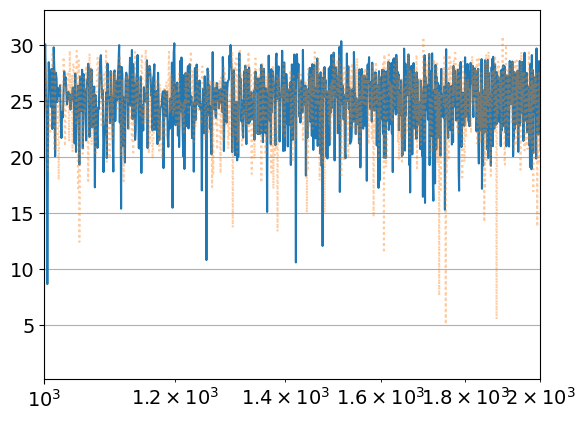

In [18]:
plt.figure()
plt.semilogx(10*np.log10(np.abs(X1)))
plt.semilogx(10*np.log10(np.abs(X2)),':', alpha = 0.4)
plt.grid()
plt.xlim((1000, 2000));